In [1]:
import os
import mne
import numpy as np
# from sentry_sdk.utils import epoch
from sklearn.preprocessing import StandardScaler
import scipy.io as sio
from torch import optim
from typing import List
from torch.utils.data import DataLoader,TensorDataset
from sklearn.metrics import classification_report,confusion_matrix
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def calculate_accuracy(loader:DataLoader,model:nn.Module,device:str)->float:
    correct = 0
    total = 0
    with torch.no_grad():
        for datas,labels in loader:
            datas,labels = datas.to(device),labels.to(device)
            outputs = model(datas)
            _,predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def get_losses(losses:List[float],loader:DataLoader,model:nn.Module,device:str)->List[float]:
    loss = 0
    with torch.no_grad():
        for i,(inputs,targets)in enumerate(loader):
            inputs,targets = inputs.to(device),targets.to(device)
            outputs = model(inputs)
            l = criterion(outputs,targets)
            loss += l.item()
        loss /= len(loader)
        losses.append(loss)
    return losses
def get_predictions(loader:DataLoader,model:nn.Module,device:str):
    all_targets = []
    all_predictions = []
    with torch.no_grad():
        for i ,(inputs,targets) in enumerate(loader):
            inputs,targets = inputs.to(device),targets.to(device)
            outputs = model(inputs)
            _,predicted = torch.max(outputs,1)
            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
    return all_targets,all_predictions

def loss_curve( epoches : int , train_losses : List[float],val_losses :List[float],model:str = '',folder_path = '',sub = '')->None:
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    plt.figure(figsize = (10,5))
    plt.plot(range(1,epoches +1),train_losses,label = 'Train Loss')
    plt.plot(range(1,epoches +1),val_losses,label = 'Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('loss')
    plt.title(f'Sub{sub+1} Training and Testing Loss Curve')
    plt.legend()
    img_path = os.path.join(folder_path,'loss_curve.png')
    plt.savefig(img_path)
    plt.show(block = False)
    plt.close()

def plot_confusion_matrix(
        all_train_targets:np.ndarray,
        all_train_predictions:np.ndarray,
        all_test_targets:np.ndarray,
        all_test_predictions:np.ndarray,
        model:str = '',
        folder_path ='',
        sub = ''
)->None:
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    plt.figure(figsize = (8,6))
    cm = confusion_matrix(all_train_targets,all_train_predictions)
    sns.heatmap(cm,annot = True,fmt = 'd',cmap = 'Blues',xticklabels = range(2),yticklabels = range(2))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Sub{sub+1} Confusion Matrix-Train')
    plt.savefig(os.path.join(folder_path,f'Sub{sub+1} Confusion Matrix-Train'))
    plt.show(block = False)
    plt.close()

    plt.figure(figsize = (8,6))
    cm = confusion_matrix(all_test_targets,all_test_predictions)
    sns.heatmap(cm,annot = True,fmt = 'd',cmap = 'Blues',xticklabels =range(2),yticklabels = range(2))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Sub{sub+1} Confusion Matrix-Test')
    plt.savefig(os.path.join(folder_path,f'Sub{sub+1} Confusion Matrix-Test'))
    plt.show(block = False)
    plt.close()

def print_Confusion_matrix(
        all_train_targets:np.ndarray,
        all_train_predictions:np.ndarray,
        all_test_targets:np.ndarray,
        all_test_predictions:np.ndarray,
        model:str = '',
        folder_path ='',
        sub = ''
):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    report_train = classification_report(all_train_targets,all_train_predictions)
    report_test  = classification_report(all_test_targets, all_test_predictions)

    with open(os.path.join(folder_path,f'Sub{sub+1}Report.txt'),'w')as f:
        f.write('\nReport Train')
        f.write(report_train)
        f.write('\nReport Test')
        f.write(report_test)

In [3]:
class EEGNet(nn.Module):
    # def __init__(self, n_classes=4, channels=22, samples=1000,
    #              dropoutRate=0.5, kernelLength=32, kernelLength2=16,
    #              F1=16, D=2, F2=32):
    def __init__(self, n_classes=2, channels=17, samples=384,
                     drop_out=0.5, kernelLength=32, kernelLength2=16,
                     F1=16, D=2, F2=32):
        super(EEGNet, self).__init__()
        self.n_classes = n_classes
        self.channels = channels
        self.samples = samples
        # self.drop_out = dropoutRate
        self.drop_out = drop_out
        self.kernelLength = kernelLength
        self.kernelLength2 = kernelLength2
        self.F1 = F1
        self.D = D
        self.F2 = F2

        block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=self.F1,
                      kernel_size=(1,self.kernelLength), stride=1,
                      padding=(0,self.kernelLength//2),
                      bias=False
        ),
            nn.BatchNorm2d(num_features=self.F1)
        )

        block2 = nn.Sequential(
            nn.Conv2d(in_channels=self.F1,out_channels=self.F1*self.D,
                      kernel_size=(self.channels,1), groups=self.F1,
                      bias=False
                      ),
            nn.BatchNorm2d(num_features=self.F1*self.D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1,8)),
            nn.Dropout(p=self.drop_out)
        )

        block3 = nn.Sequential(
            nn.Conv2d(in_channels=self.F1*self.D,out_channels=self.F2,
                      kernel_size=(1,self.kernelLength2), stride=1,
                      padding=(0,self.kernelLength2//2),groups=self.F1*self.D,
                      bias=False
                      ),
            nn.Conv2d(in_channels=self.F2,out_channels=self.F2,
                      kernel_size=(1,1), stride=1,
                      bias=False),
            nn.BatchNorm2d(num_features=self.F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1,16)),
            nn.Dropout(p=self.drop_out)
        )

        self.EEGNetLayer = nn.Sequential(block1, block2, block3)
        # self.FlattenLayer = nn.Flatten()
        self.ClassifierBlock = nn.Sequential(nn.Linear(in_features=self.F2 * round((self.samples // 8) // 16),
                                                       out_features=self.n_classes,
                                                       bias=False),
                                             nn.Softmax(dim=1)
        )
        # self.model = nn.Sequential(self.EEGNetLayer, self.FlattenLayer, self.ClassifierBlock)
    def forward(self, x):
        if len(x.shape) != 4:
            x = torch.unsqueeze(x,1)
        x = self.EEGNetLayer(x)
        x = x.view(x.size()[0], -1)  # Flatten # [N, self.F2*1*T/32]
        x = self.ClassifierBlock(x)
        # x = self.model(x)

        return x

In [4]:
import h5py
import numpy as np

# 读取文件
with h5py.File('seed.mat', 'r') as f:
    # 查看文件里有哪些键（可选）
    print("文件中的变量：", list(f.keys()))

    # 提取数据（注意 v7.3 文件里数组通常需要转置或额外处理）
    EEGsample = np.array(f['EEGsample'])
    subindex   = np.array(f['subindex'])
    substate   = np.array(f['substate'])
    EEGsample = EEGsample.transpose(2,1,0)
print("EEGsample shape:", EEGsample.shape)
print("subindex shape:", subindex.shape)
print("substate shape:", substate.shape)


文件中的变量： ['EEGsample', 'subindex', 'substate']
EEGsample shape: (11396, 17, 384)
subindex shape: (1, 11396)
substate shape: (1, 11396)


In [5]:
save_path = os.path.join(os.getcwd(), 'results')
if not os.path.exists(save_path):
    os.makedirs(save_path)

path = os.path.join(save_path, 'EEGNet')
if not os.path.exists(path):
    os.makedirs(path)
report_path = os.path.join(path, 'report.txt')

torch.manual_seed(2024)

=== 数据维度检查 ===
inpt.shape  = torch.Size([11396, 1, 17, 384])
label.shape = torch.Size([11396])
index.shape = torch.Size([11396])

========== 开始 10 折交叉验证 ==========

========== 第 1/10 折 ==========
Fold [1/10], Epoch [1/500], Step [1/41], Loss: 0.6989
Fold [1/10], Epoch [1/500], Step [11/41], Loss: 0.6911
Fold [1/10], Epoch [1/500], Step [21/41], Loss: 0.6847
Fold [1/10], Epoch [1/500], Step [31/41], Loss: 0.6837
Fold [1/10], Epoch [1/500], Step [41/41], Loss: 0.6635
Fold [1/10], Epoch [101/500], Step [1/41], Loss: 0.4804
Fold [1/10], Epoch [101/500], Step [11/41], Loss: 0.4358
Fold [1/10], Epoch [101/500], Step [21/41], Loss: 0.4951
Fold [1/10], Epoch [101/500], Step [31/41], Loss: 0.4502
Fold [1/10], Epoch [101/500], Step [41/41], Loss: 0.5464
Fold [1/10], Epoch [201/500], Step [1/41], Loss: 0.4726
Fold [1/10], Epoch [201/500], Step [11/41], Loss: 0.4222
Fold [1/10], Epoch [201/500], Step [21/41], Loss: 0.4385
Fold [1/10], Epoch [201/500], Step [31/41], Loss: 0.4378
Fold [1/10], Epoch 

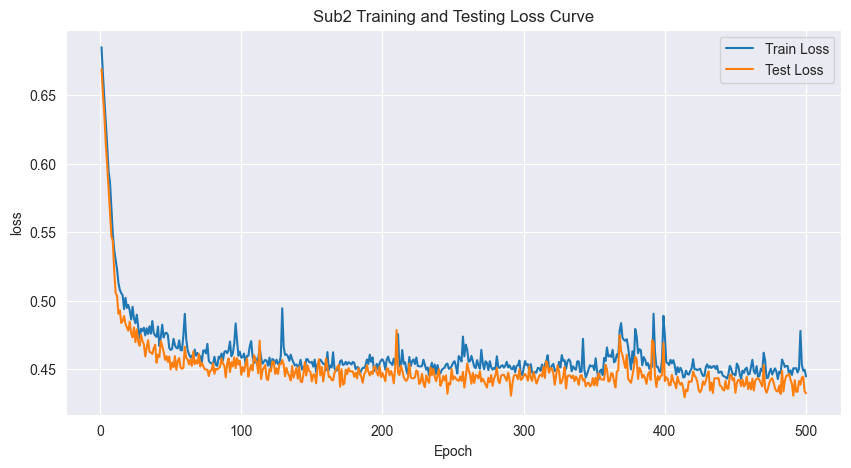

<Figure size 640x480 with 0 Axes>

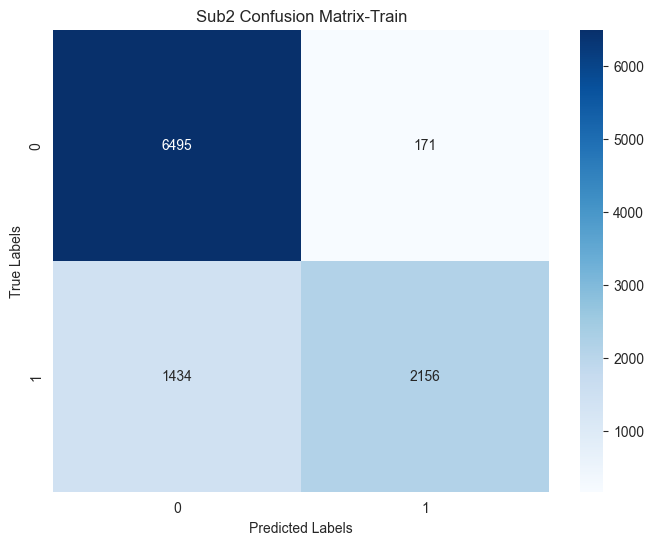

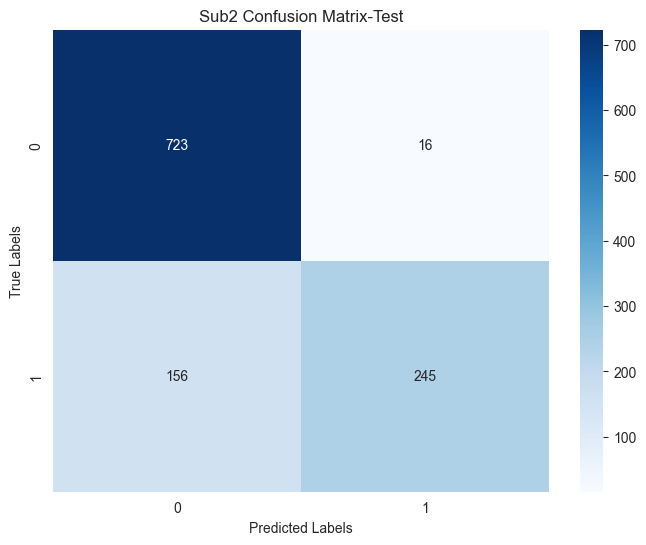

第 1 折 测试准确率: 84.91%

========== 第 2/10 折 ==========
Fold [2/10], Epoch [1/500], Step [1/41], Loss: 0.6998
Fold [2/10], Epoch [1/500], Step [11/41], Loss: 0.6883
Fold [2/10], Epoch [1/500], Step [21/41], Loss: 0.6853
Fold [2/10], Epoch [1/500], Step [31/41], Loss: 0.6824
Fold [2/10], Epoch [1/500], Step [41/41], Loss: 0.6972
Fold [2/10], Epoch [101/500], Step [1/41], Loss: 0.4685
Fold [2/10], Epoch [101/500], Step [11/41], Loss: 0.4652
Fold [2/10], Epoch [101/500], Step [21/41], Loss: 0.4771
Fold [2/10], Epoch [101/500], Step [31/41], Loss: 0.4591
Fold [2/10], Epoch [101/500], Step [41/41], Loss: 0.4493
Fold [2/10], Epoch [201/500], Step [1/41], Loss: 0.4802
Fold [2/10], Epoch [201/500], Step [11/41], Loss: 0.4619
Fold [2/10], Epoch [201/500], Step [21/41], Loss: 0.4602
Fold [2/10], Epoch [201/500], Step [31/41], Loss: 0.4486
Fold [2/10], Epoch [201/500], Step [41/41], Loss: 0.3758
Fold [2/10], Epoch [301/500], Step [1/41], Loss: 0.4491
Fold [2/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

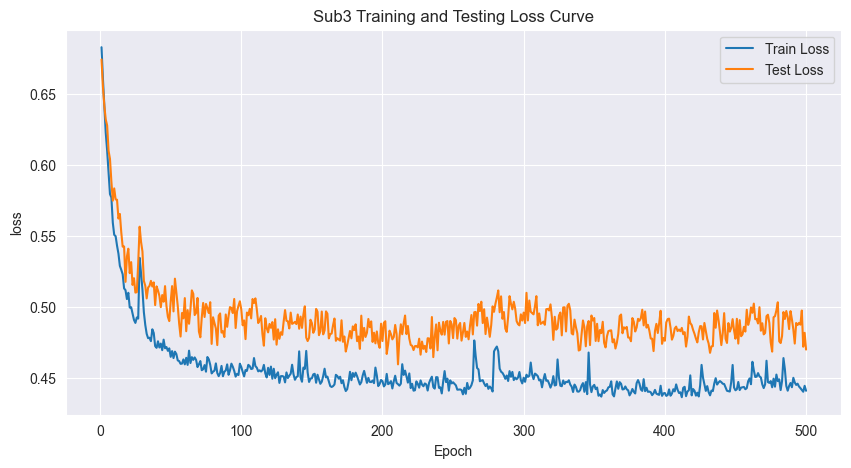

<Figure size 640x480 with 0 Axes>

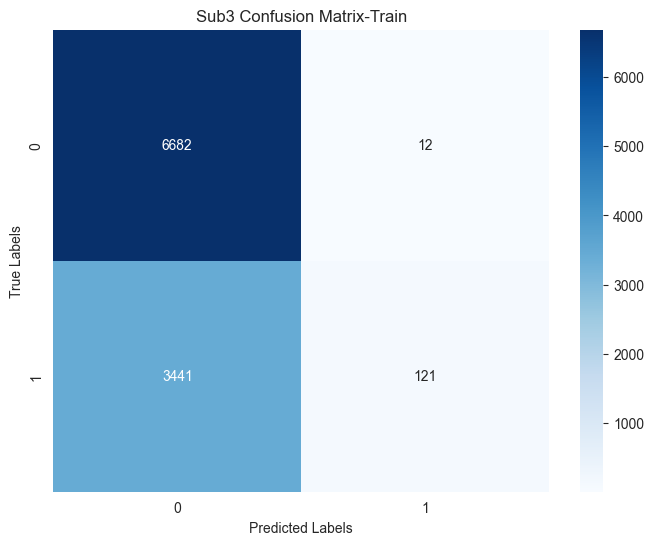

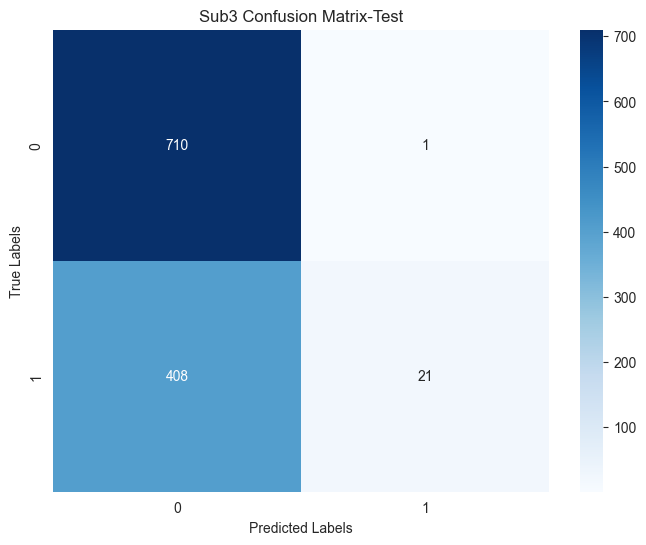

第 2 折 测试准确率: 64.12%

========== 第 3/10 折 ==========
Fold [3/10], Epoch [1/500], Step [1/41], Loss: 0.6980
Fold [3/10], Epoch [1/500], Step [11/41], Loss: 0.6966
Fold [3/10], Epoch [1/500], Step [21/41], Loss: 0.6857
Fold [3/10], Epoch [1/500], Step [31/41], Loss: 0.6596
Fold [3/10], Epoch [1/500], Step [41/41], Loss: 0.6529
Fold [3/10], Epoch [101/500], Step [1/41], Loss: 0.4238
Fold [3/10], Epoch [101/500], Step [11/41], Loss: 0.4739
Fold [3/10], Epoch [101/500], Step [21/41], Loss: 0.4500
Fold [3/10], Epoch [101/500], Step [31/41], Loss: 0.4757
Fold [3/10], Epoch [101/500], Step [41/41], Loss: 0.3997
Fold [3/10], Epoch [201/500], Step [1/41], Loss: 0.5001
Fold [3/10], Epoch [201/500], Step [11/41], Loss: 0.4397
Fold [3/10], Epoch [201/500], Step [21/41], Loss: 0.4145
Fold [3/10], Epoch [201/500], Step [31/41], Loss: 0.4618
Fold [3/10], Epoch [201/500], Step [41/41], Loss: 0.4467
Fold [3/10], Epoch [301/500], Step [1/41], Loss: 0.5052
Fold [3/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

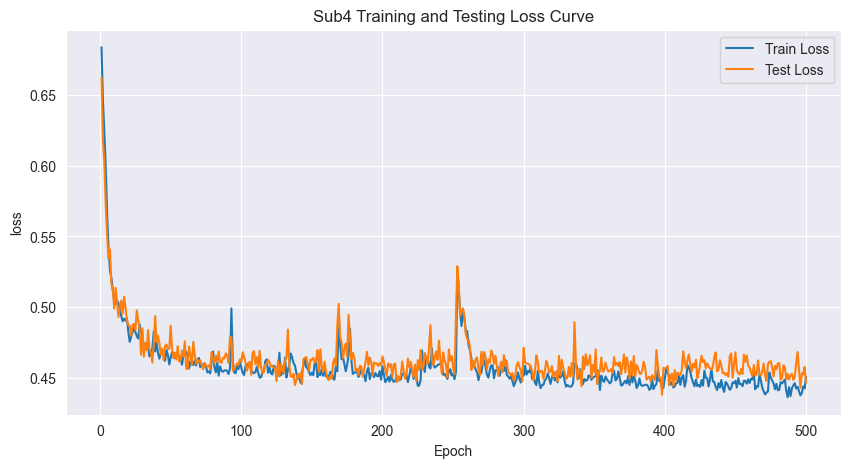

<Figure size 640x480 with 0 Axes>

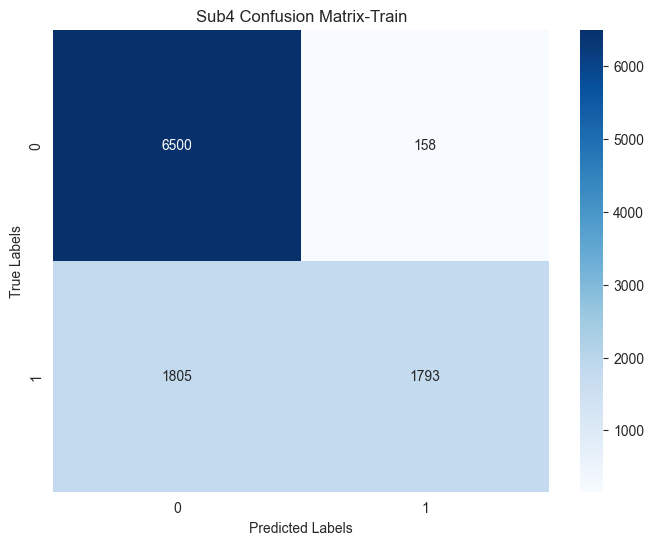

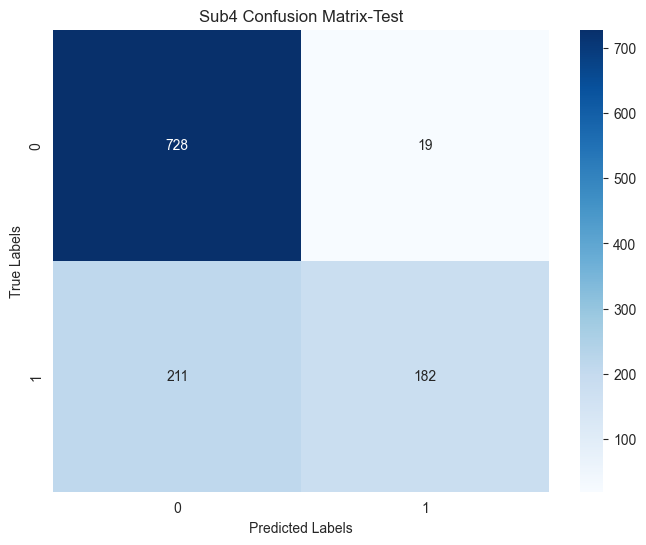

第 3 折 测试准确率: 79.82%

========== 第 4/10 折 ==========
Fold [4/10], Epoch [1/500], Step [1/41], Loss: 0.6933
Fold [4/10], Epoch [1/500], Step [11/41], Loss: 0.6848
Fold [4/10], Epoch [1/500], Step [21/41], Loss: 0.6814
Fold [4/10], Epoch [1/500], Step [31/41], Loss: 0.6780
Fold [4/10], Epoch [1/500], Step [41/41], Loss: 0.6585
Fold [4/10], Epoch [101/500], Step [1/41], Loss: 0.4501
Fold [4/10], Epoch [101/500], Step [11/41], Loss: 0.4739
Fold [4/10], Epoch [101/500], Step [21/41], Loss: 0.4392
Fold [4/10], Epoch [101/500], Step [31/41], Loss: 0.4435
Fold [4/10], Epoch [101/500], Step [41/41], Loss: 0.5119
Fold [4/10], Epoch [201/500], Step [1/41], Loss: 0.4604
Fold [4/10], Epoch [201/500], Step [11/41], Loss: 0.4044
Fold [4/10], Epoch [201/500], Step [21/41], Loss: 0.4398
Fold [4/10], Epoch [201/500], Step [31/41], Loss: 0.4350
Fold [4/10], Epoch [201/500], Step [41/41], Loss: 0.4738
Fold [4/10], Epoch [301/500], Step [1/41], Loss: 0.4470
Fold [4/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

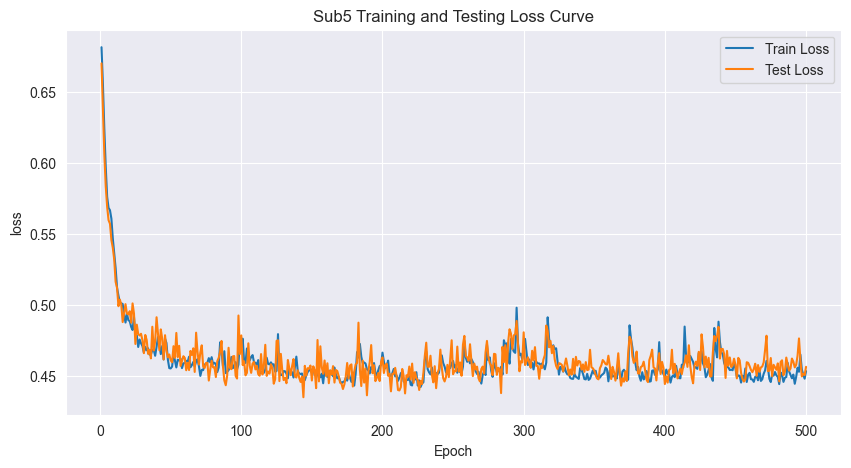

<Figure size 640x480 with 0 Axes>

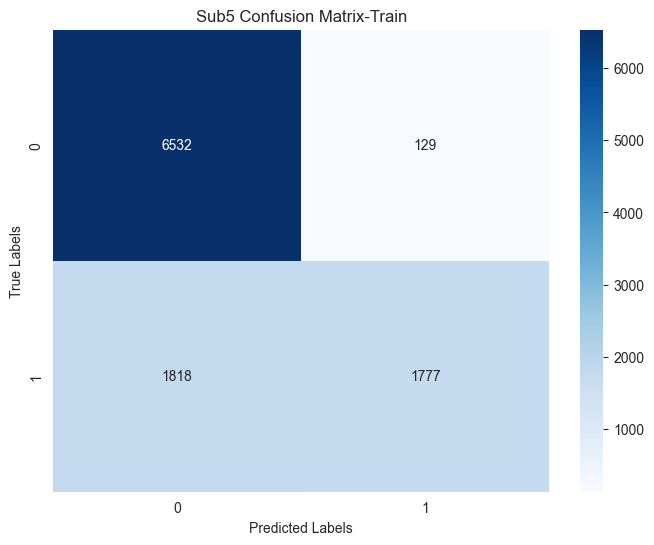

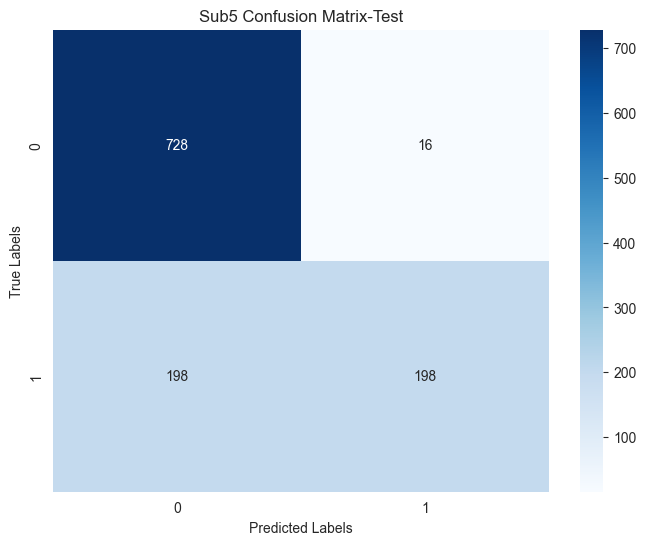

第 4 折 测试准确率: 81.23%

========== 第 5/10 折 ==========
Fold [5/10], Epoch [1/500], Step [1/41], Loss: 0.7051
Fold [5/10], Epoch [1/500], Step [11/41], Loss: 0.6915
Fold [5/10], Epoch [1/500], Step [21/41], Loss: 0.6898
Fold [5/10], Epoch [1/500], Step [31/41], Loss: 0.6820
Fold [5/10], Epoch [1/500], Step [41/41], Loss: 0.5952
Fold [5/10], Epoch [101/500], Step [1/41], Loss: 0.4769
Fold [5/10], Epoch [101/500], Step [11/41], Loss: 0.4720
Fold [5/10], Epoch [101/500], Step [21/41], Loss: 0.4844
Fold [5/10], Epoch [101/500], Step [31/41], Loss: 0.4650
Fold [5/10], Epoch [101/500], Step [41/41], Loss: 0.5356
Fold [5/10], Epoch [201/500], Step [1/41], Loss: 0.4250
Fold [5/10], Epoch [201/500], Step [11/41], Loss: 0.5080
Fold [5/10], Epoch [201/500], Step [21/41], Loss: 0.4693
Fold [5/10], Epoch [201/500], Step [31/41], Loss: 0.4679
Fold [5/10], Epoch [201/500], Step [41/41], Loss: 0.4565
Fold [5/10], Epoch [301/500], Step [1/41], Loss: 0.4752
Fold [5/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

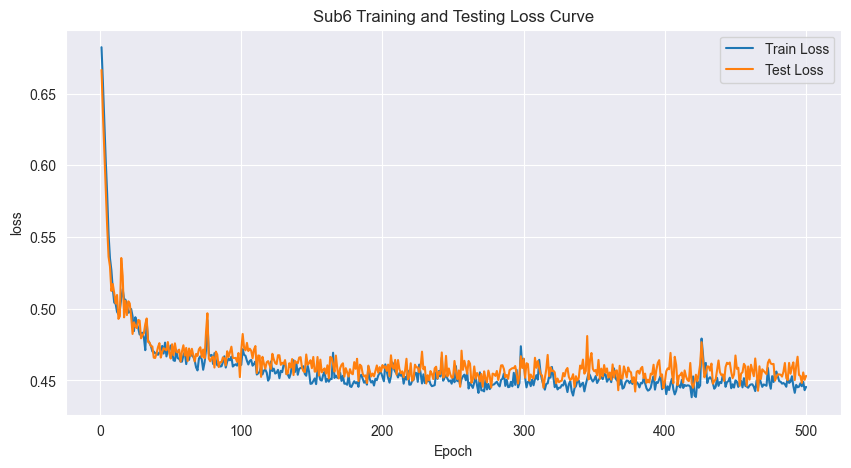

<Figure size 640x480 with 0 Axes>

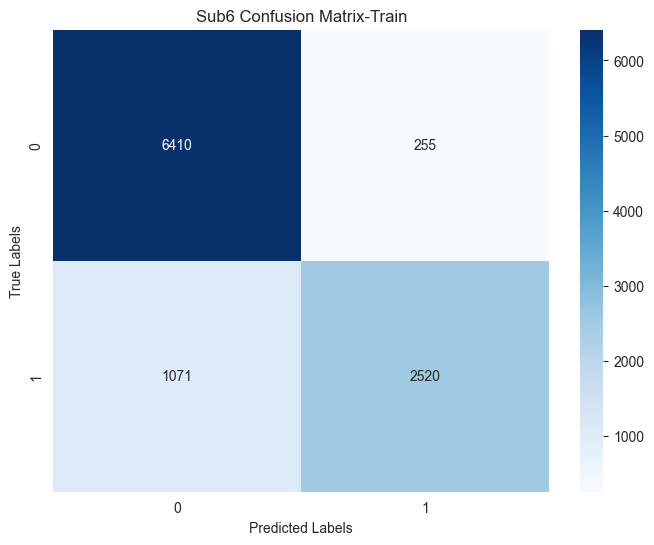

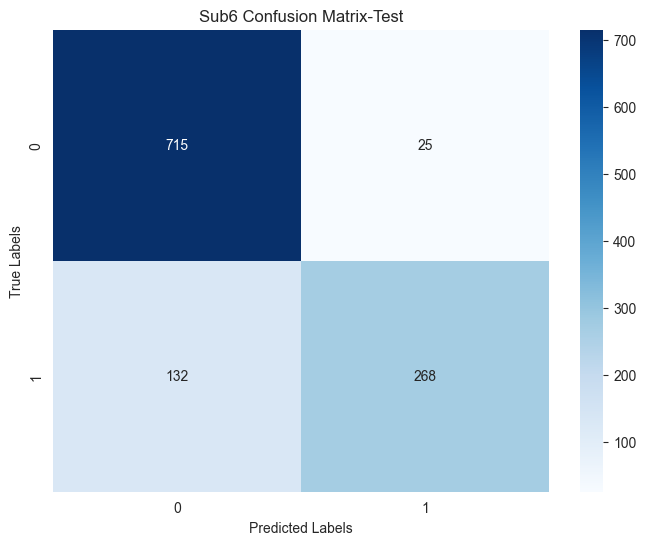

第 5 折 测试准确率: 86.23%

========== 第 6/10 折 ==========
Fold [6/10], Epoch [1/500], Step [1/41], Loss: 0.6986
Fold [6/10], Epoch [1/500], Step [11/41], Loss: 0.6981
Fold [6/10], Epoch [1/500], Step [21/41], Loss: 0.6918
Fold [6/10], Epoch [1/500], Step [31/41], Loss: 0.6756
Fold [6/10], Epoch [1/500], Step [41/41], Loss: 0.7043
Fold [6/10], Epoch [101/500], Step [1/41], Loss: 0.4830
Fold [6/10], Epoch [101/500], Step [11/41], Loss: 0.4461
Fold [6/10], Epoch [101/500], Step [21/41], Loss: 0.4870
Fold [6/10], Epoch [101/500], Step [31/41], Loss: 0.4728
Fold [6/10], Epoch [101/500], Step [41/41], Loss: 0.4740
Fold [6/10], Epoch [201/500], Step [1/41], Loss: 0.4214
Fold [6/10], Epoch [201/500], Step [11/41], Loss: 0.4573
Fold [6/10], Epoch [201/500], Step [21/41], Loss: 0.4456
Fold [6/10], Epoch [201/500], Step [31/41], Loss: 0.4313
Fold [6/10], Epoch [201/500], Step [41/41], Loss: 0.3795
Fold [6/10], Epoch [301/500], Step [1/41], Loss: 0.4408
Fold [6/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

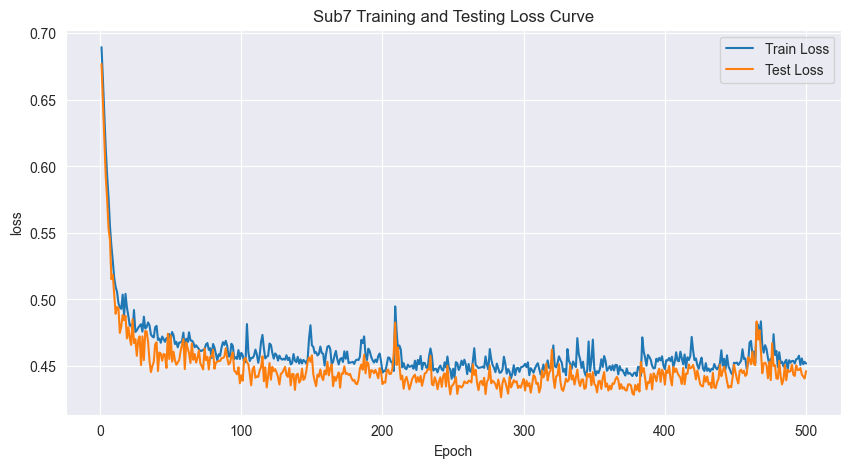

<Figure size 640x480 with 0 Axes>

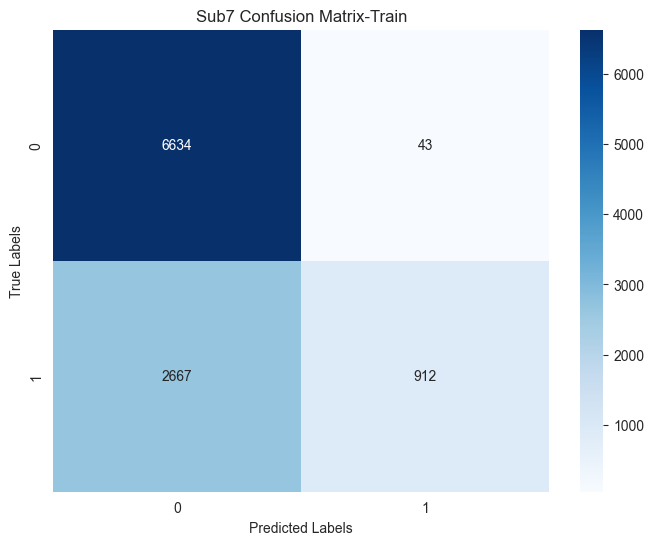

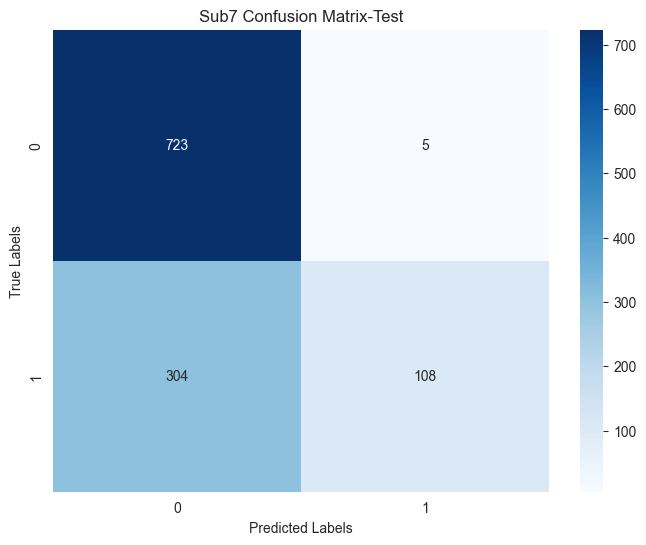

第 6 折 测试准确率: 72.89%

========== 第 7/10 折 ==========
Fold [7/10], Epoch [1/500], Step [1/41], Loss: 0.6873
Fold [7/10], Epoch [1/500], Step [11/41], Loss: 0.6844
Fold [7/10], Epoch [1/500], Step [21/41], Loss: 0.6823
Fold [7/10], Epoch [1/500], Step [31/41], Loss: 0.6722
Fold [7/10], Epoch [1/500], Step [41/41], Loss: 0.7244
Fold [7/10], Epoch [101/500], Step [1/41], Loss: 0.4173
Fold [7/10], Epoch [101/500], Step [11/41], Loss: 0.4345
Fold [7/10], Epoch [101/500], Step [21/41], Loss: 0.4430
Fold [7/10], Epoch [101/500], Step [31/41], Loss: 0.4403
Fold [7/10], Epoch [101/500], Step [41/41], Loss: 0.3158
Fold [7/10], Epoch [201/500], Step [1/41], Loss: 0.4616
Fold [7/10], Epoch [201/500], Step [11/41], Loss: 0.4964
Fold [7/10], Epoch [201/500], Step [21/41], Loss: 0.4765
Fold [7/10], Epoch [201/500], Step [31/41], Loss: 0.4611
Fold [7/10], Epoch [201/500], Step [41/41], Loss: 0.3823
Fold [7/10], Epoch [301/500], Step [1/41], Loss: 0.4599
Fold [7/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

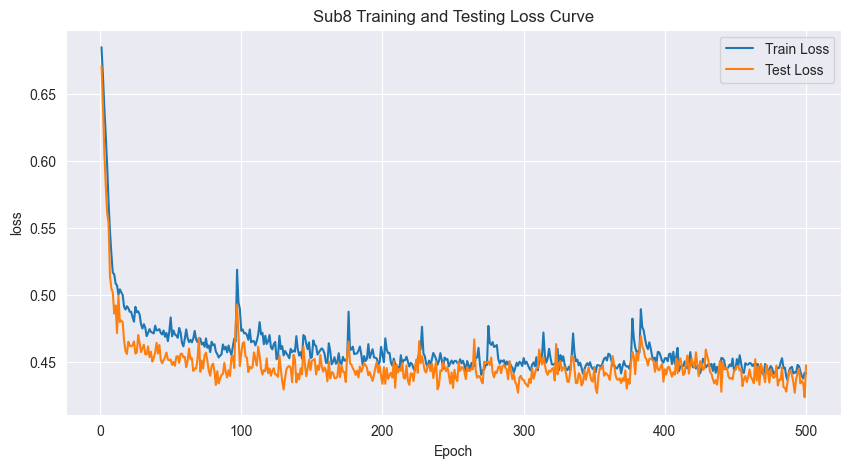

<Figure size 640x480 with 0 Axes>

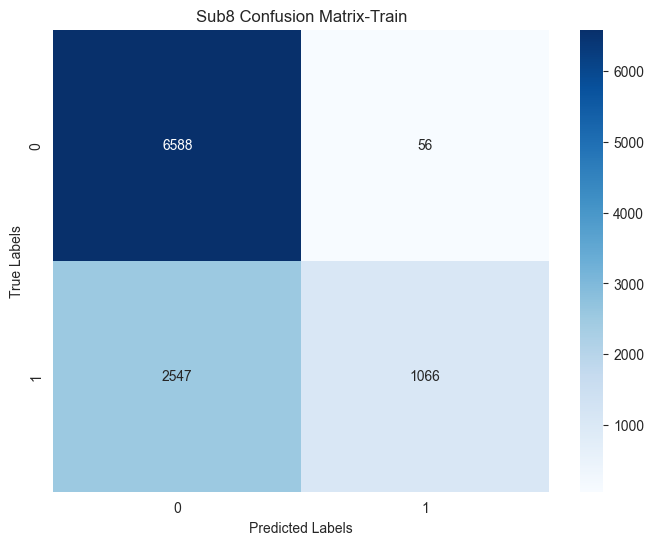

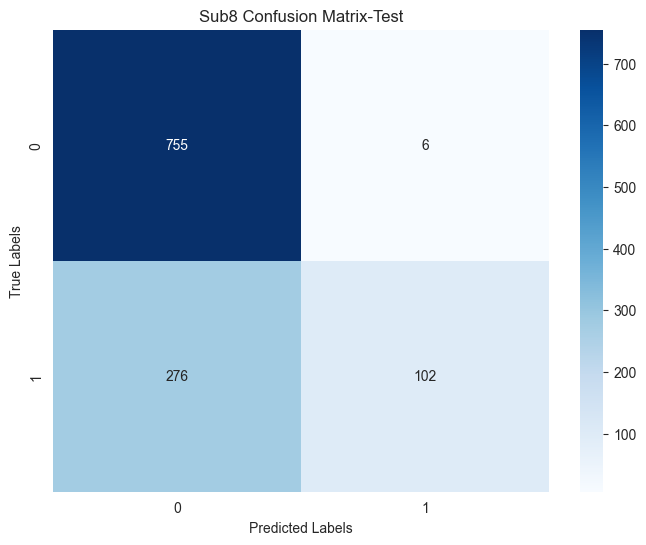

第 7 折 测试准确率: 75.24%

========== 第 8/10 折 ==========
Fold [8/10], Epoch [1/500], Step [1/41], Loss: 0.7008
Fold [8/10], Epoch [1/500], Step [11/41], Loss: 0.6924
Fold [8/10], Epoch [1/500], Step [21/41], Loss: 0.6889
Fold [8/10], Epoch [1/500], Step [31/41], Loss: 0.6797
Fold [8/10], Epoch [1/500], Step [41/41], Loss: 0.6545
Fold [8/10], Epoch [101/500], Step [1/41], Loss: 0.4238
Fold [8/10], Epoch [101/500], Step [11/41], Loss: 0.4240
Fold [8/10], Epoch [101/500], Step [21/41], Loss: 0.4469
Fold [8/10], Epoch [101/500], Step [31/41], Loss: 0.4457
Fold [8/10], Epoch [101/500], Step [41/41], Loss: 0.4772
Fold [8/10], Epoch [201/500], Step [1/41], Loss: 0.4459
Fold [8/10], Epoch [201/500], Step [11/41], Loss: 0.4753
Fold [8/10], Epoch [201/500], Step [21/41], Loss: 0.4441
Fold [8/10], Epoch [201/500], Step [31/41], Loss: 0.4932
Fold [8/10], Epoch [201/500], Step [41/41], Loss: 0.5042
Fold [8/10], Epoch [301/500], Step [1/41], Loss: 0.4279
Fold [8/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

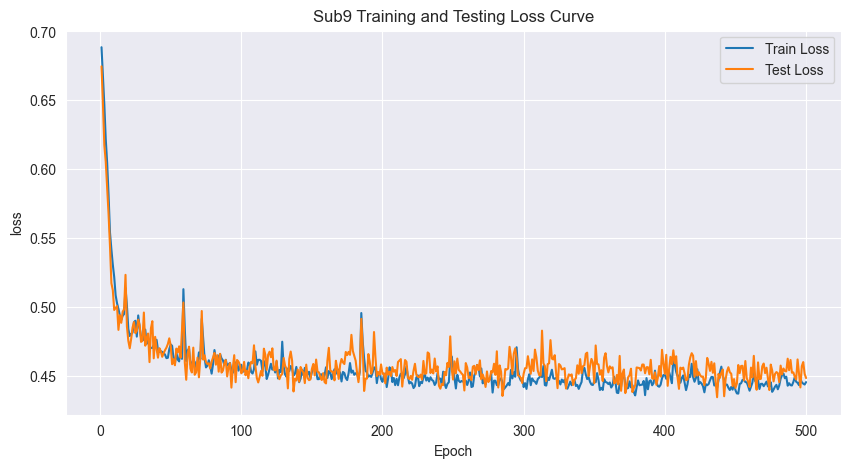

<Figure size 640x480 with 0 Axes>

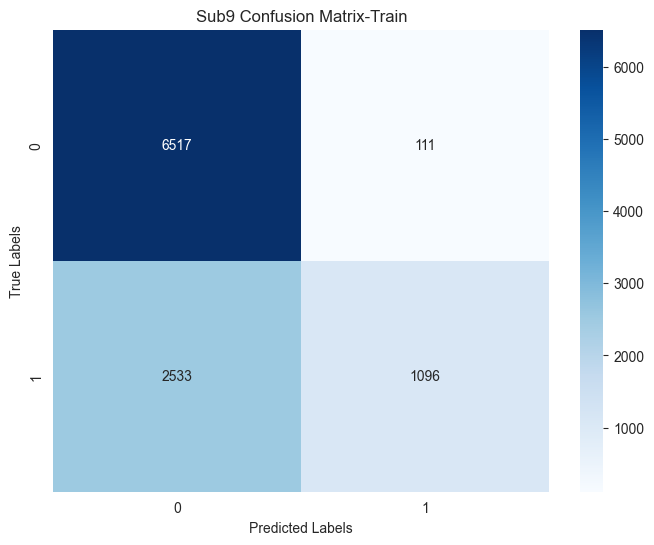

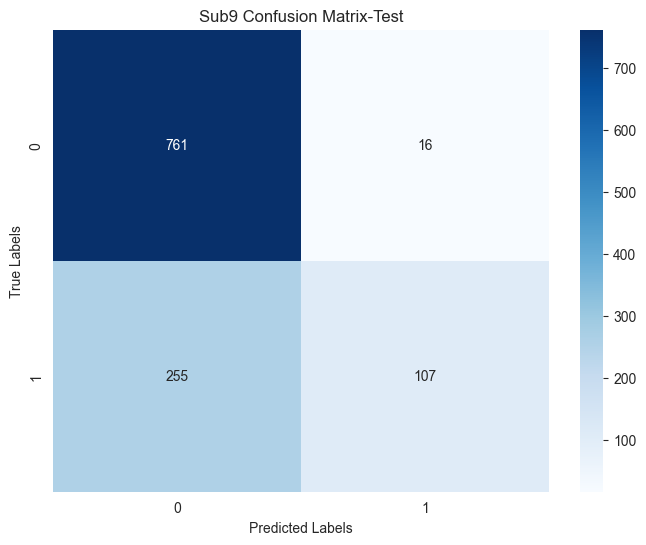

第 8 折 测试准确率: 76.21%

========== 第 9/10 折 ==========
Fold [9/10], Epoch [1/500], Step [1/41], Loss: 0.6834
Fold [9/10], Epoch [1/500], Step [11/41], Loss: 0.6858
Fold [9/10], Epoch [1/500], Step [21/41], Loss: 0.6849
Fold [9/10], Epoch [1/500], Step [31/41], Loss: 0.6692
Fold [9/10], Epoch [1/500], Step [41/41], Loss: 0.6356
Fold [9/10], Epoch [101/500], Step [1/41], Loss: 0.4620
Fold [9/10], Epoch [101/500], Step [11/41], Loss: 0.4374
Fold [9/10], Epoch [101/500], Step [21/41], Loss: 0.4881
Fold [9/10], Epoch [101/500], Step [31/41], Loss: 0.4718
Fold [9/10], Epoch [101/500], Step [41/41], Loss: 0.3581
Fold [9/10], Epoch [201/500], Step [1/41], Loss: 0.4314
Fold [9/10], Epoch [201/500], Step [11/41], Loss: 0.4346
Fold [9/10], Epoch [201/500], Step [21/41], Loss: 0.4051
Fold [9/10], Epoch [201/500], Step [31/41], Loss: 0.4718
Fold [9/10], Epoch [201/500], Step [41/41], Loss: 0.6013
Fold [9/10], Epoch [301/500], Step [1/41], Loss: 0.4487
Fold [9/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

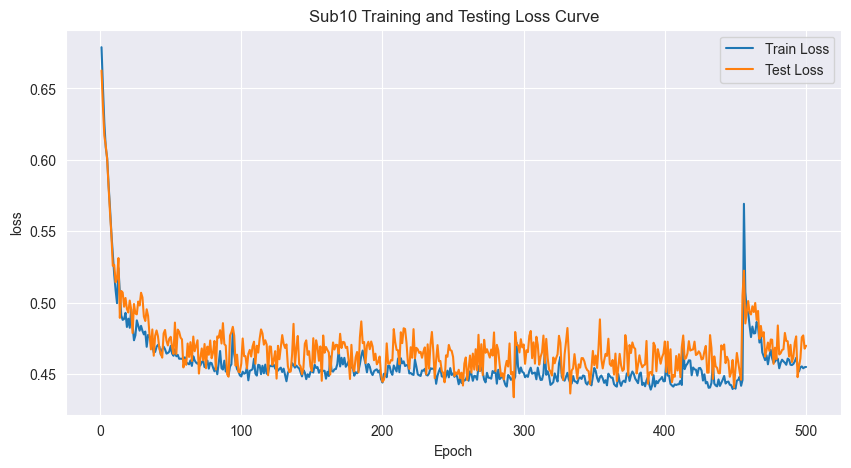

<Figure size 640x480 with 0 Axes>

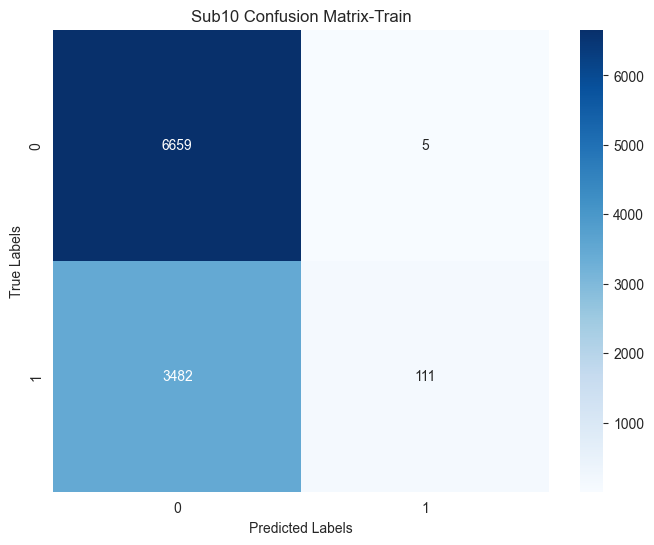

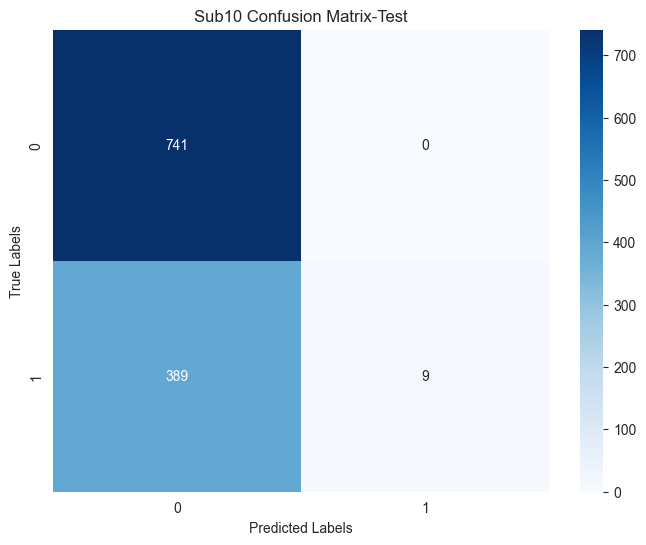

第 9 折 测试准确率: 65.85%

========== 第 10/10 折 ==========
Fold [10/10], Epoch [1/500], Step [1/41], Loss: 0.6973
Fold [10/10], Epoch [1/500], Step [11/41], Loss: 0.6891
Fold [10/10], Epoch [1/500], Step [21/41], Loss: 0.6846
Fold [10/10], Epoch [1/500], Step [31/41], Loss: 0.6848
Fold [10/10], Epoch [1/500], Step [41/41], Loss: 0.5989
Fold [10/10], Epoch [101/500], Step [1/41], Loss: 0.4382
Fold [10/10], Epoch [101/500], Step [11/41], Loss: 0.4820
Fold [10/10], Epoch [101/500], Step [21/41], Loss: 0.4743
Fold [10/10], Epoch [101/500], Step [31/41], Loss: 0.4863
Fold [10/10], Epoch [101/500], Step [41/41], Loss: 0.3774
Fold [10/10], Epoch [201/500], Step [1/41], Loss: 0.4216
Fold [10/10], Epoch [201/500], Step [11/41], Loss: 0.4199
Fold [10/10], Epoch [201/500], Step [21/41], Loss: 0.4857
Fold [10/10], Epoch [201/500], Step [31/41], Loss: 0.4281
Fold [10/10], Epoch [201/500], Step [41/41], Loss: 0.3931
Fold [10/10], Epoch [301/500], Step [1/41], Loss: 0.4547
Fold [10/10], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

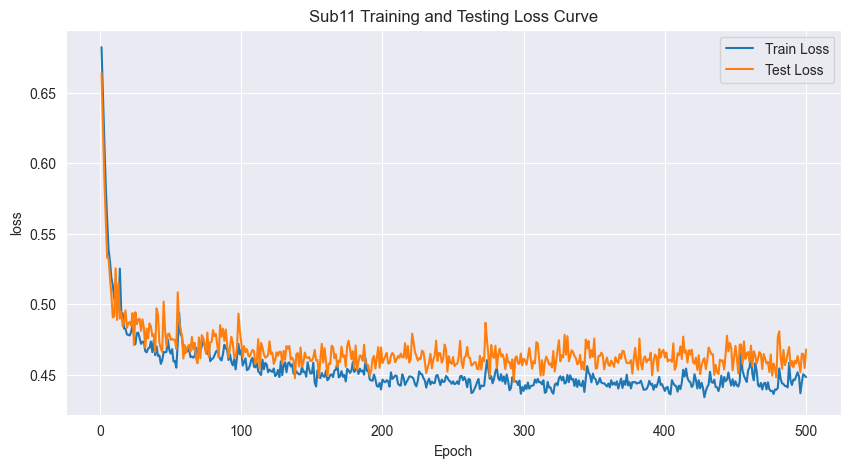

<Figure size 640x480 with 0 Axes>

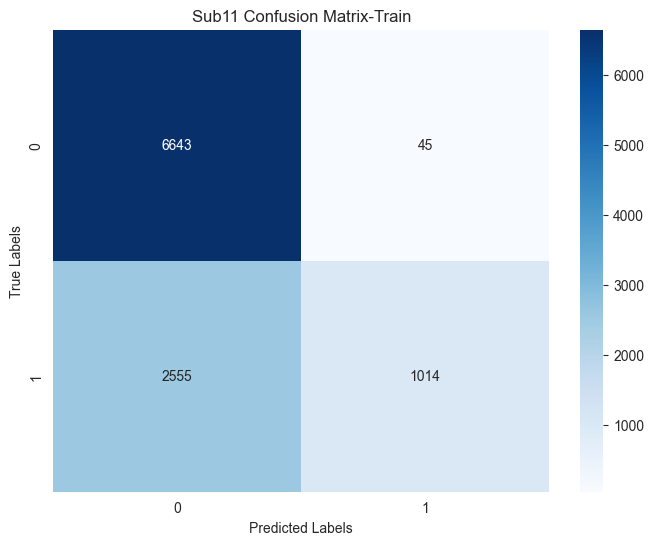

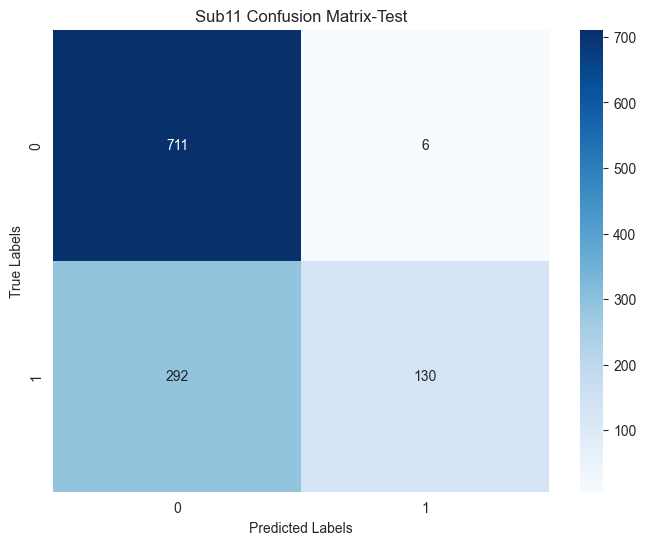

第 10 折 测试准确率: 73.84%

========== 10 折交叉验证最终结果 ==========
平均测试准确率: 76.03% (±6.96%)
各折准确率: ['84.91%', '64.12%', '79.82%', '81.23%', '86.23%', '72.89%', '75.24%', '76.21%', '65.85%', '73.84%']


<Figure size 640x480 with 0 Axes>

In [6]:
datas = []
test_datas = []

# 定义超参数（保持不变）
lr = 0.01
wd = 0.001
bs = 256
op = 'SGD'
dr = 0.5
epoches = 500
all_loocv_accuracies = []  # 新增：保存11次LOOCV的准确率
all_loocv_train_losses = []  # 新增：保存11次的训练损失
all_loocv_test_losses = []   # 新增：保存11次的测试损失

import numpy as np
from sklearn.model_selection import KFold
import torch
from torch.utils.data import TensorDataset, DataLoader

# ====================== 原始数据处理（建议加上 squeeze） ======================
predata = torch.Tensor(EEGsample)
label = torch.Tensor(substate).long().squeeze()           # 确保一维
index = torch.Tensor(subindex).long().squeeze() - 1       # 确保一维，形状 [11396]

inpt = predata.reshape(-1, 1, 17, 384)                    # (11396, 1, 17, 384)

print("=== 数据维度检查 ===")
print("inpt.shape  =", inpt.shape)
print("label.shape =", label.shape)
print("index.shape =", index.shape)

# ====================== 改为 10-Fold Cross Validation ======================
n_folds = 10
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)   # random_state 保证可复现

all_fold_accuracies = []
all_fold_train_losses = []
all_fold_test_losses = []

print(f"\n========== 开始 {n_folds} 折交叉验证 ==========")

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(inpt)):
    print(f"\n========== 第 {fold_idx+1}/{n_folds} 折 ==========")

    # 1. 根据索引拆分数据（直接用 numpy/pytorch 的 advanced indexing）
    train_inpt  = inpt[train_idx]
    train_label = label[train_idx]
    test_inpt   = inpt[test_idx]
    test_label  = label[test_idx]

    # 2. 构建 Dataset 和 DataLoader
    train_dataset = TensorDataset(train_inpt, train_label)
    test_dataset  = TensorDataset(test_inpt, test_label)

    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=bs, shuffle=False)

    # 3. 每次折都重新初始化模型和优化器（非常重要）
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net = EEGNet(drop_out=dr).to(device)

    criterion = nn.CrossEntropyLoss().to(device)
    if op == 'Adam':
        optimizer = optim.Adam(net.parameters(), lr=lr, weight_decay=wd)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoches, eta_min=0)
    else:
        optimizer = optim.SGD(net.parameters(), lr=lr, weight_decay=wd, momentum=0.9, nesterov=True)

    # 4. 训练循环（保持你原来的逻辑）
    train_losses = []
    test_losses = []

    for epoch in range(epoches):
        net.train()
        train_loss = 0.0

        for i, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            if op == 'Adam':
                scheduler.step()

            if epoch % 100 == 0 and i % 10 == 0:
                print(f'Fold [{fold_idx+1}/{n_folds}], Epoch [{epoch+1}/{epoches}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # 测试损失（调用你原来的 get_losses 函数）
        test_losses = get_losses(test_losses, test_loader, net, device)

    # 5. 评估本折结果
    net.eval()
    all_train_targets, all_train_predictions = get_predictions(train_loader, net, device)
    all_test_targets, all_test_predictions   = get_predictions(test_loader, net, device)

    # 保存曲线和混淆矩阵（保持你原来的路径逻辑）
    sub_path = os.path.join(path, 'EEGNet', f'fold_{fold_idx+1}')
    os.makedirs(sub_path, exist_ok=True)
    loss_curve(epoches, train_losses, test_losses, folder_path=sub_path, sub=fold_idx+1)
    plt.clf()
    plot_confusion_matrix(all_train_targets, all_train_predictions,
                         all_test_targets, all_test_predictions,
                         folder_path=sub_path, sub=fold_idx+1)
    plt.clf()

    # 计算准确率
    test_accuracy = calculate_accuracy(test_loader, net, device)
    all_fold_accuracies.append(test_accuracy)
    print(f'第 {fold_idx+1} 折 测试准确率: {test_accuracy:.2f}%')

    # 保存损失
    all_fold_train_losses.append(train_losses)
    all_fold_test_losses.append(test_losses)

# ====================== 最终结果 ======================
mean_accuracy = np.mean(all_fold_accuracies)
std_accuracy  = np.std(all_fold_accuracies)

print(f"\n========== {n_folds} 折交叉验证最终结果 ==========")
print(f'平均测试准确率: {mean_accuracy:.2f}% (±{std_accuracy:.2f}%)')
print(f'各折准确率: {[f"{acc:.2f}%" for acc in all_fold_accuracies]}')

# 写入报告
with open(report_path, 'a') as f:
    f.write(f'\n{n_folds}-Fold CV 平均准确率: {mean_accuracy:.2f}% (标准差: {std_accuracy:.2f}%)\n')
    f.write(f'各折准确率: {[f"{acc:.2f}%" for acc in all_fold_accuracies]}\n')